In [147]:
import sys
import pandas as pd
import numpy as np
import torch

from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments    
)

import matplotlib.pyplot as plt

# Adiciona o diretório src ao path de forma mais robusta
sys.path.insert(0, '../')

from src import RepositorioDados
from src import evaluate_and_visualize

# Detecta o dispositivo e a precisão usada nas operações
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if (device.type == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32
print(f"Device: {device} | Precision: {dtype}")

# Seed para resultados reproduzíveis
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Device: cpu | Precision: torch.float32


In [148]:
# ==================== CONFIGURAÇÕES PRÉ-TREINAMENTO ====================
TIMESTAMP_COLUMN = 'timestamp'  # Coluna com timestamps
TARGET_COLUMN = ['Vol']     # Coluna a prever (volatilidade)
LAGS = 5
USE_MEAN_FEATURES = False     # Incluir médias móveis como features
ID_COLUMNS = []             # Sem IDs (série única)

# Tamanhos das janelas: histórico 7 dias, previsão 1 dia (dados diários)
CONTEXT_LENGTH = 256         # Janela histórica: x dias passados
FORECAST_HORIZON = 1        # Prever: x dias à frente

TRAIN_FRAC, VALID_FRAC = 0.7, 0.1  # Frações treino/validação/teste

# Hyperparâmetros do modelo
PATCH_LENGTH = 8            # Tamanho do patch (1=sem patchificação, mantém cada dia)
BATCH_SIZE = 32             # Samples por batch (reduzir se GPU memory limitada)
NUM_WORKERS = 0             # Workers para data loading (0 em Windows)
EPOCHS = 50                 # Reduzido: 50→30 (volatilidade tem ciclos curtos)
LEARNING_RATE = 5e-4        # Taxa de aprendizado

D_MODEL = 64              # Dimensão do modelo (embedding)
NUM_ATTENTION_HEADS = 16     # Número de cabeças de atenção
NUM_HIDDEN_LAYERS = 2      # Número de camadas ocultas (reduzido para evitar overfitting)
FFN_DIM = 128              # Dimensão da feedforward network (aumentado para compensar menos camadas)
DROPOUT = 0.05              # Taxa de dropout
ATTENTION_DROPOUT = DROPOUT
SCALING = False            # Desativar escalonamento (já normalizamos os dados)

In [149]:
repo = RepositorioDados()
tsp, train_ds, valid_ds, test_ds, train_df, valid_df, test_df = repo.executar(timestamp_col=TIMESTAMP_COLUMN, train_frac=TRAIN_FRAC, valid_frac=VALID_FRAC, context_length=CONTEXT_LENGTH, target_col=TARGET_COLUMN, id_columns=ID_COLUMNS, forecast_horizon=FORECAST_HORIZON, use_mean_features=USE_MEAN_FEATURES, lags=LAGS)

Carregando dados de C:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt
Calculando features de volatilidade


In [150]:
# ==================== MÉTRICAS DE AVALIAÇÃO ====================
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(eval_pred):
    pred, labels = eval_pred
    pred = pred[0] if isinstance(pred, tuple) else pred

    # 1-step ahead
    pred_1 = pred[:, 0, 0]
    label_1 = labels[:, 0, 0]

    mse = mean_squared_error(label_1, pred_1)
    mae = mean_absolute_error(label_1, pred_1)
    rmse = np.sqrt(mse)
    mape = np.mean(
        np.abs((label_1 - pred_1) / (np.abs(label_1) + 1e-9))
    ) * 100

    return {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [151]:
config = PatchTSTConfig(
    context_length=CONTEXT_LENGTH,
    patch_length=PATCH_LENGTH,
    num_input_channels=len(TARGET_COLUMN),
    patch_stride=PATCH_LENGTH,
    prediction_length=FORECAST_HORIZON,
    d_model=D_MODEL,
    num_attention_heads=NUM_ATTENTION_HEADS,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    ffn_dim=FFN_DIM,
    dropout=DROPOUT,
    head_dropout=ATTENTION_DROPOUT,
    pooling_type=None,
    channel_attention=True, # Ativação da atenção entre canais
    loss='mse',
    pre_norm=True,
    norm_type='batchnorm',
)

# config = PatchTSTConfig(
#             do_mask_input=False,
#             context_length=context_length,
#             patch_length=patch_length,
#             num_input_channels=len(config_params['target_col']),
#             patch_stride=patch_length,
#             prediction_length=forecast_horizon,
#             d_model=d_model,
#             num_attention_heads=num_attention_heads,
#             num_hidden_layers=num_hidden_layers,
#             ffn_dim=ffn_dim,
#             dropout=dropout,
#             head_dropout=dropout,
#             pooling_type=None,
#             channel_attention=True,
#             scaling='std',
#             loss='mse',
#             pre_norm=True,
#             norm_type='batchnorm',
#         )

model = PatchTSTForPrediction(
    config=config
    ).to(device).to(dtype)

In [152]:
train_args = TrainingArguments(
    output_dir="../models/patchtst_volatility",
    overwrite_output_dir=True,
    learning_rate=LEARNING_RATE,
    num_train_epochs=EPOCHS,
    do_eval=True,
    eval_strategy="epoch",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    dataloader_num_workers=NUM_WORKERS,
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    fp16=(dtype == torch.float16),
    bf16=(dtype == torch.bfloat16),
    logging_dir="../logs/logs_patchtst_volatility",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    label_names=["future_values"]
)

early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=7,
    early_stopping_threshold=0.0
)

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]
)

In [153]:
print("Iniciando o treinamento do PatchTST para volatilidade...")
trainer.train()

Iniciando o treinamento do PatchTST para volatilidade...


Epoch,Training Loss,Validation Loss,Mse,Mae,Rmse,Mape
1,0.645800,0.036530,0.036530,0.102217,0.191129,65.836084
2,0.583300,0.029917,0.029917,0.097346,0.172966,51.179969
3,0.566400,0.028299,0.028299,0.089800,0.168225,52.754915
4,0.557100,0.027025,0.027025,0.079989,0.164393,43.849087
5,0.553700,0.027385,0.027385,0.075413,0.165485,47.695833
6,0.552700,0.027369,0.027369,0.076618,0.165435,45.586136
7,0.545700,0.027286,0.027286,0.090460,0.165186,45.803255
8,0.592000,0.027456,0.027456,0.079722,0.165699,45.938832
9,0.548100,0.029382,0.029382,0.092520,0.171412,43.960631
10,0.534000,0.028290,0.028290,0.083338,0.168197,42.347470


TrainOutput(global_step=528, training_loss=0.5659310998338641, metrics={'train_runtime': 28.4773, 'train_samples_per_second': 2688.106, 'train_steps_per_second': 84.278, 'total_flos': 1859194664448.0, 'train_loss': 0.5659310998338641, 'epoch': 11.0})

In [154]:
# MODEL_DIR = "../models/patchtst/context256_lags5_useFalse"

# # Usa a config salva junto ao modelo para evitar divergências
# config = PatchTSTConfig.from_pretrained(MODEL_DIR)

# # Carrega pesos safetensors da pasta (não use torch.load direto)
# model = PatchTSTForPrediction.from_pretrained(
#     MODEL_DIR,
#     config=config,
#     local_files_only=True,
#     dtype=dtype
# ).to(device)

# model.eval()
# print(f"Modelo carregado de {MODEL_DIR}")
import os
model_save_path = f"../models/patchtst/context{CONTEXT_LENGTH}_lags{LAGS}_use{str(USE_MEAN_FEATURES)}_v3"
trainer.save_model(model_save_path)


=== Scratch ===
MSE: 8.234245e-07
MAE: 3.841426e-04
RMSE: 9.074274e-04
MAPE: 1.041620e+02


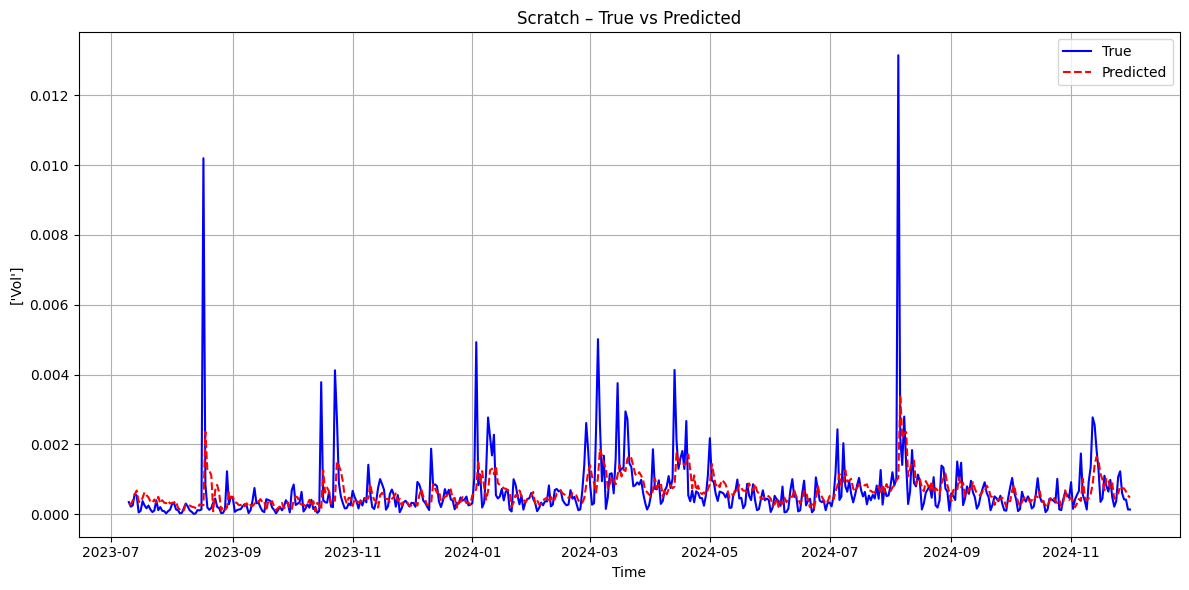

In [155]:
train_df = train_ds.datasets[0].data_df
test_df = test_ds.datasets[0].data_df

forecast, results = evaluate_and_visualize(
    model=model,
    test_dataset=test_ds,
    tsp=tsp,
    test_df=test_df,
    timestamp_col=TIMESTAMP_COLUMN,
    target_column=TARGET_COLUMN,
    context_length=CONTEXT_LENGTH,
    model_name="Scratch"
    )

Carregando dados de C:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt
Calculando features de volatilidade
Avaliando modelo HAR...

=== AVALIAÇÃO FINAL - LinearRegression (HAR) ===
TREINO:
  MSE: 1.643883e-05
  MAE: 1.248940e-03
  RMSE: 4.054483e-03
  MAPE: 1.221932e+02

TESTE:
  MSE: 9.247747e-07
  MAE: 5.332288e-04
  RMSE: 9.616521e-04
  MAPE: 2.188558e+02

Visualizando previsões no conjunto de teste...


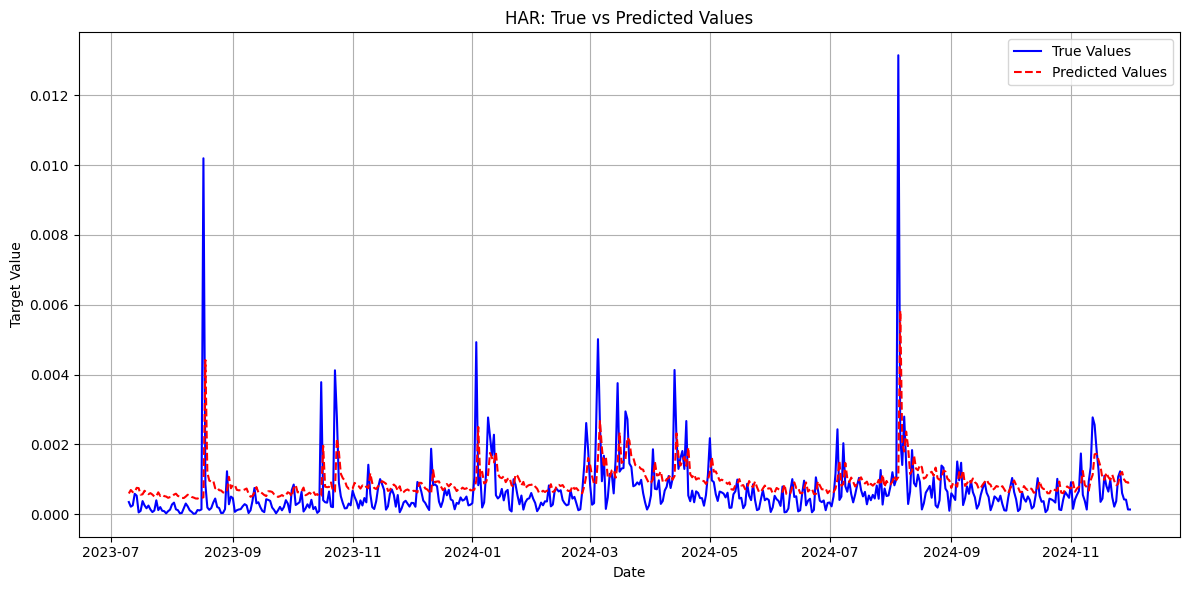

In [156]:
from src import HarModel, BTC_DATA_FILE

repo = RepositorioDados()
df_har = repo.load_and_prepare_data(file_path=BTC_DATA_FILE, timestamp_col=TIMESTAMP_COLUMN)
df_har = repo.calculate_features(df_har, timestamp_col=TIMESTAMP_COLUMN, lags=1, use_mean_features=True)

print("Avaliando modelo HAR...")
test_df = df_har[df_har[TIMESTAMP_COLUMN].isin(forecast)]

X_train = df_har[~df_har[TIMESTAMP_COLUMN].isin(forecast)].drop(['timestamp', 'Vol'], axis=1).values
y_train = df_har.loc[~df_har[TIMESTAMP_COLUMN].isin(forecast), TARGET_COLUMN].values

X_test = df_har[df_har[TIMESTAMP_COLUMN].isin(forecast)].drop(['timestamp', 'Vol'], axis=1).values
y_test = df_har.loc[df_har[TIMESTAMP_COLUMN].isin(forecast), TARGET_COLUMN].values
test_dates = df_har.loc[df_har[TIMESTAMP_COLUMN].isin(forecast), TIMESTAMP_COLUMN].values

har = HarModel()
har.train(X_train, y_train)

y_pred_train = har.predict(X_train)
y_pred_test  = har.predict(X_test)

har.evaluate_and_visualize(
    y_train, y_pred_train,
    y_test, y_pred_test,
    test_dates=test_dates
)

In [157]:
# ==================== CARREGAR MODELO PRÉ-TREINADO ====================

BASE_MODEL = "ibm-granite/granite-timeseries-patchtst"

# Configuração: adapta modelo genérico para seu dataset
config = PatchTSTConfig.from_pretrained(BASE_MODEL)
config.num_input_channels = len(TARGET_COLUMN)  # 1 feature (Vol)

# Carrega weights pré-treinados
model_zero = PatchTSTForPrediction.from_pretrained(
    BASE_MODEL,
    config=config
).to(device).to(dtype)

print(f"Modelo carregado: {BASE_MODEL}")
print(f"Num parâmetros: {model.num_parameters():,}")

Modelo carregado: ibm-granite/granite-timeseries-patchtst
Num parâmetros: 71,873


In [158]:
repo_zero = RepositorioDados()
tsp_zero, train_ds_zero, valid_ds_zero, test_ds_zero, train_df_zero, valid_df_zero, test_df_zero = repo_zero.executar(timestamp_col=TIMESTAMP_COLUMN, train_frac=TRAIN_FRAC, valid_frac=VALID_FRAC, context_length=512, target_col=TARGET_COLUMN, id_columns=ID_COLUMNS, forecast_horizon=96, use_mean_features=True, lags=3)

Carregando dados de C:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt
Calculando features de volatilidade


In [159]:
def inverse_transform_targets_zero(tsp, values, target_column):
    scaler = next(iter(tsp.target_scaler_dict.values()))
    mean = scaler.mean_[0]
    std = scaler.scale_[0]
    return values * std + mean


# ============================================================
# Avaliação + Plot
# ============================================================

def evaluate_and_visualize_zero(
    model,
    test_dataset,
    tsp,
    test_df,
    timestamp_col,
    target_column,
    context_length,
    forecast,
    model_name="Modelo",
):
    # Predict
    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir="metric_temp",
            per_device_eval_batch_size=32,
            label_names=["future_values"]
        )
    )

    outputs = trainer.predict(test_dataset)

    preds = outputs.predictions
    labels = outputs.label_ids

    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.array(preds)
    labels = np.array(labels)

    # Padroniza shape
    if preds.ndim == 2:
        preds = preds[..., None]
        labels = labels[..., None]

    # Desnormalização
    preds_real = inverse_transform_targets_zero(tsp, preds, target_column)
    labels_real = inverse_transform_targets_zero(tsp, labels, target_column)

    # 1-step de cada janela
    preds_first = preds_real[:, 0, 0]
    labels_first = labels_real[:, 0, 0]

    # Parte final da última janela (multi-step)
    tail_steps = max(forecast - 1, 0)
    preds_tail = preds_real[-1, 1 : 1 + tail_steps, 0] if tail_steps else np.array([])
    labels_tail = labels_real[-1, 1 : 1 + tail_steps, 0] if tail_steps else np.array([])

    # Concatena 1-step de cada janela + resto da última
    preds_full = np.concatenate([preds_first, preds_tail])
    labels_full = np.concatenate([labels_first, labels_tail])

    # Datas alinhadas
    dates = test_df[timestamp_col].values
    dates_first = dates[context_length : context_length + len(preds_first)]
    tail_start = context_length + len(preds_first)
    dates_tail = dates[tail_start : tail_start + len(preds_tail)]
    forecast_dates_full = np.concatenate([dates_first, dates_tail])

    # Métricas
    metrics_first = {
        "MSE": mean_squared_error(labels_first, preds_first),
        "MAE": mean_absolute_error(labels_first, preds_first),
        "RMSE": np.sqrt(mean_squared_error(labels_first, preds_first)),
        "MAPE": np.mean(
            np.abs((labels_first - preds_first) / (np.abs(labels_first) + 1e-8))
        ) * 100
    }
    metrics_full = {
        "MSE": mean_squared_error(labels_full, preds_full),
        "MAE": mean_absolute_error(labels_full, preds_full),
        "RMSE": np.sqrt(mean_squared_error(labels_full, preds_full)),
        "MAPE": np.mean(
            np.abs((labels_full - preds_full) / (np.abs(labels_full) + 1e-8))
        ) * 100
    }

    print(f"\n=== {model_name} ===")
    print("1-step metrics:")
    for k, v in metrics_first.items():
        print(f"{k}: {v:.6e}")
    if len(preds_tail) > 0:
        print("\nMerged (1-step + tail) metrics:")
        for k, v in metrics_full.items():
            print(f"{k}: {v:.6e}")

    # Plot usando apenas 1-step para evitar sobreposição
    plt.figure(figsize=(12, 6))
    plt.plot(forecast_dates_full, labels_full, label="True", color='blue')
    plt.plot(forecast_dates_full, preds_full, "--", label="Predicted", color='red')
    plt.title(f"{model_name} – True vs Predicted (1-step)")
    plt.xlabel("Time")
    plt.ylabel(str(target_column))
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    results = {
        "metrics_first": metrics_first,
        "metrics_full": metrics_full,
        "dates_first": dates_first,
        "dates_full": forecast_dates_full,
        "preds_first": preds_first,
        "labels_first": labels_first,
        "preds_full": preds_full,
        "labels_full": labels_full,
    }

    return forecast_dates_full, results


Avaliando modelo zero shot...



=== Zero-Shot ===
1-step metrics:
MSE: 1.142447e-06
MAE: 6.195743e-04
RMSE: 1.068853e-03
MAPE: 3.126337e+02

Merged (1-step + tail) metrics:
MSE: 1.104461e-06
MAE: 6.574836e-04
RMSE: 1.050933e-03
MAPE: 3.165521e+02


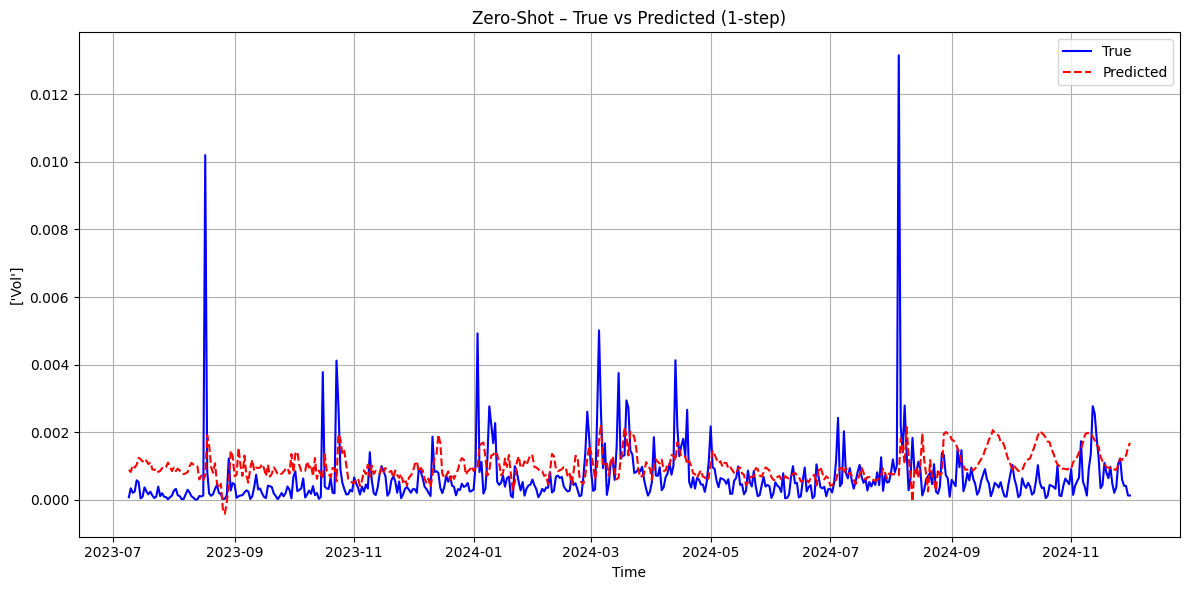

In [160]:
print("Avaliando modelo zero shot...")
forecast_dates_zeroshot, results_zeroshot = evaluate_and_visualize_zero(
    model=model_zero,
    test_dataset=test_ds_zero,
    tsp=tsp_zero,
    test_df=test_df_zero,
    timestamp_col=TIMESTAMP_COLUMN,
    target_column=TARGET_COLUMN,
    context_length=512,
    forecast=96,
    model_name="Zero-Shot",
)